In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sn


In [113]:
df = pd.read_csv('emi_prediction_dataset.csv')

C:\Users\Admin\AppData\Local\Temp\ipykernel_7000\24023947.py:1: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('emi_prediction_dataset.csv')


In [114]:
dir(pd)

['ArrowDtype',
 'BooleanDtype',
 'Categorical',
 'CategoricalDtype',
 'CategoricalIndex',
 'DataFrame',
 'DateOffset',
 'DatetimeIndex',
 'DatetimeTZDtype',
 'ExcelFile',
 'ExcelWriter',
 'Flags',
 'Float32Dtype',
 'Float64Dtype',
 'Grouper',
 'HDFStore',
 'Index',
 'IndexSlice',
 'Int16Dtype',
 'Int32Dtype',
 'Int64Dtype',
 'Int8Dtype',
 'Interval',
 'IntervalDtype',
 'IntervalIndex',
 'MultiIndex',
 'NA',
 'NaT',
 'NamedAgg',
 'Period',
 'PeriodDtype',
 'PeriodIndex',
 'RangeIndex',
 'Series',
 'SparseDtype',
 'StringDtype',
 'Timedelta',
 'TimedeltaIndex',
 'Timestamp',
 'UInt16Dtype',
 'UInt32Dtype',
 'UInt64Dtype',
 'UInt8Dtype',
 '__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__docformat__',
 '__file__',
 '__git_version__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '__version__',
 '_built_with_meson',
 '_config',
 '_is_numpy_dev',
 '_libs',
 '_pandas_datetime_CAPI',
 '_pandas_parser_CAPI',
 '_testing',
 '_typing',
 '_version_meson',
 'annota

In [115]:
pd.set_option('display.max_columns',None)

In [116]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi
0,38.0,Female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0
1,38.0,Female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0
2,38.0,Male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0
3,58.0,Female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0
4,48.0,Female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0


In [117]:
# since we have to create both classification and regression model .. there are 2 target cols
# one for classification and one for regression
# when one col is target for one model .. the other act as feature for that model.

In [118]:
df.shape

(404800, 27)

In [119]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi'],
      dtype='object')

In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 27 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     404800 non-null  object 
 1   gender                  404800 non-null  object 
 2   marital_status          404800 non-null  object 
 3   education               402396 non-null  object 
 4   monthly_salary          404800 non-null  object 
 5   employment_type         404800 non-null  object 
 6   years_of_employment     404800 non-null  float64
 7   company_type            404800 non-null  object 
 8   house_type              404800 non-null  object 
 9   monthly_rent            402374 non-null  float64
 10  family_size             404800 non-null  int64  
 11  dependents              404800 non-null  int64  
 12  school_fees             404800 non-null  float64
 13  college_fees            404800 non-null  float64
 14  travel_expenses     

In [121]:
obj_cols=df.select_dtypes(include=['object']).columns
obj_cols

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'company_type', 'house_type', 'existing_loans',
       'bank_balance', 'emi_scenario', 'emi_eligibility'],
      dtype='object')

In [122]:
num_cols=df.select_dtypes(include=['float64','int64']).columns
num_cols

Index(['years_of_employment', 'monthly_rent', 'family_size', 'dependents',
       'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'current_emi_amount', 'credit_score',
       'emergency_fund', 'requested_amount', 'requested_tenure',
       'max_monthly_emi'],
      dtype='object')

In [123]:
obj_cols.shape[0] + num_cols.shape[0]

27

In [124]:
df.isnull().sum()

age                          0
gender                       0
marital_status               0
education                 2404
monthly_salary               0
employment_type              0
years_of_employment          0
company_type                 0
house_type                   0
monthly_rent              2426
family_size                  0
dependents                   0
school_fees                  0
college_fees                 0
travel_expenses              0
groceries_utilities          0
other_monthly_expenses       0
existing_loans               0
current_emi_amount           0
credit_score              2420
bank_balance              2426
emergency_fund            2351
emi_scenario                 0
requested_amount             0
requested_tenure             0
emi_eligibility              0
max_monthly_emi              0
dtype: int64

In [125]:
df.education.value_counts()

education
Graduate         181015
Post Graduate    100314
High School       60732
Professional      60335
Name: count, dtype: int64

In [126]:
df['education'].fillna('Graduate', inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7000\3654388140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['education'].fillna('Graduate', inplace=True)


In [127]:
# next monthly_rent with 2426 NA


In [128]:
df.monthly_rent.skew()

np.float64(1.6123843959223387)

In [129]:
# this is a large dataset .. so if skew is >1 we'll use median .. if lesser use mean ...
df.monthly_rent.fillna(df.monthly_rent.median(),inplace=True)

C:\Users\Admin\AppData\Local\Temp\ipykernel_7000\34939860.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.monthly_rent.fillna(df.monthly_rent.median(),inplace=True)


In [130]:
# next credit_score with 2420 NA
df.credit_score.skew()

np.float64(-1.0940635046891765)

In [131]:
# not b/w 1to-1 so median
df.credit_score = df.credit_score.fillna(df.credit_score.median())

In [132]:
# next bank_balance with 2426 NA
# df.bank_balance.skew()
# this seeems like a obj type .. but the entries are actually numbers .. lets change its type

In [133]:
df['bank_balance'] = pd.to_numeric(df['bank_balance'], errors='coerce')
# errors='coerce'makes the unchangeable values into NA

In [134]:
df.bank_balance.dtype

dtype('float64')

In [135]:
df.bank_balance.isnull().sum()

np.int64(4392)

In [136]:
df.bank_balance.skew()

np.float64(1.4142824175129096)

In [137]:
df.bank_balance = df.bank_balance.fillna(df.bank_balance.median())

In [138]:
# next emergency_fund with 2351 NA
df.emergency_fund.skew()


np.float64(1.7899995023706674)

In [139]:
df.emergency_fund = df.emergency_fund.fillna(df.emergency_fund.median())

In [140]:
df.isnull().sum()

age                       0
gender                    0
marital_status            0
education                 0
monthly_salary            0
employment_type           0
years_of_employment       0
company_type              0
house_type                0
monthly_rent              0
family_size               0
dependents                0
school_fees               0
college_fees              0
travel_expenses           0
groceries_utilities       0
other_monthly_expenses    0
existing_loans            0
current_emi_amount        0
credit_score              0
bank_balance              0
emergency_fund            0
emi_scenario              0
requested_amount          0
requested_tenure          0
emi_eligibility           0
max_monthly_emi           0
dtype: int64

In [141]:
obj_cols=df.select_dtypes(include=['object']).columns
obj_cols

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'company_type', 'house_type', 'existing_loans',
       'emi_scenario', 'emi_eligibility'],
      dtype='object')

In [142]:
num_cols=df.select_dtypes(include=['float64','int64']).columns
num_cols

Index(['years_of_employment', 'monthly_rent', 'family_size', 'dependents',
       'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'current_emi_amount', 'credit_score',
       'bank_balance', 'emergency_fund', 'requested_amount',
       'requested_tenure', 'max_monthly_emi'],
      dtype='object')

In [143]:
df[obj_cols].head()

,age,gender,marital_status,education,monthly_salary,employment_type,company_type,house_type,existing_loans,emi_scenario,emi_eligibility
0,38.0,Female,Married,Professional,82600.0,Private,Mid-size,Rented,Yes,Personal Loan EMI,Not_Eligible
1,38.0,Female,Married,Graduate,21500.0,Private,MNC,Family,Yes,E-commerce Shopping EMI,Not_Eligible
2,38.0,Male,Married,Professional,86100.0,Private,Startup,Own,No,Education EMI,Eligible
3,58.0,Female,Married,High School,66800.0,Private,Mid-size,Own,No,Vehicle EMI,Eligible
4,48.0,Female,Married,Professional,57300.0,Private,Mid-size,Family,No,Home Appliances EMI,Not_Eligible


In [144]:
df.gender.unique()

array(['Female', 'Male', 'female', 'male', 'M', 'MALE', 'F', 'FEMALE'],
      dtype=object)

In [145]:
df['gender'] = df['gender'].str.strip().str.lower() # theres no spaces still using it simply
df['gender'] = df['gender'].replace({'m': 'male', 'f': 'female'})

In [146]:
df.gender.unique()

array(['female', 'male'], dtype=object)

In [147]:
df['gender_num'] = pd.get_dummies(df.gender, drop_first=True)

In [148]:
df.gender_num.unique()

array([False,  True])

In [149]:
df.marital_status.unique()

array(['Married', 'Single'], dtype=object)

In [150]:
df['marital_status_num'] = pd.get_dummies(df.marital_status, drop_first=True)

In [151]:
df.marital_status_num.unique()

array([False,  True])

In [152]:
df.education.unique()

array(['Professional', 'Graduate', 'High School', 'Post Graduate'],
      dtype=object)

In [153]:
# this is ordinal data so well map it manually

edu_map = {
    'High School': 1,
    'Graduate': 2,
    'Post Graduate': 3,
    'Professional': 4
}
df['education_num'] = df['education'].map(edu_map)

df.education_num.unique()


array([4, 2, 1, 3])

In [154]:
df.monthly_salary.dtype

dtype('O')

In [155]:
#since its like bank_balance .. we'll change it stype and deal with NA if it creates any cos of using errors='coerce'
df.monthly_salary = pd.to_numeric(df.monthly_salary, errors='coerce')
print(df.monthly_salary.dtype)
print(df.monthly_salary.isnull().sum())

float64
1993


In [156]:
df.monthly_salary.skew()

np.float64(4.833036897501728)

In [157]:
df.monthly_salary = df.monthly_salary.fillna(df.monthly_salary.median())
df.monthly_salary.isnull().sum()

np.int64(0)

In [158]:
obj_cols = obj_cols.drop('monthly_salary')

In [159]:
num_cols = num_cols.append(pd.Index(['monthly_salary']))

In [160]:
print(obj_cols)
print(num_cols)
print(obj_cols.shape[0]+num_cols.shape[0])

Index(['age', 'gender', 'marital_status', 'education', 'employment_type',
       'company_type', 'house_type', 'existing_loans', 'emi_scenario',
       'emi_eligibility'],
      dtype='object')
Index(['years_of_employment', 'monthly_rent', 'family_size', 'dependents',
       'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'current_emi_amount', 'credit_score',
       'bank_balance', 'emergency_fund', 'requested_amount',
       'requested_tenure', 'max_monthly_emi', 'monthly_salary'],
      dtype='object')
27


In [161]:
df[obj_cols].head()

,age,gender,marital_status,education,employment_type,company_type,house_type,existing_loans,emi_scenario,emi_eligibility
0,38.0,female,Married,Professional,Private,Mid-size,Rented,Yes,Personal Loan EMI,Not_Eligible
1,38.0,female,Married,Graduate,Private,MNC,Family,Yes,E-commerce Shopping EMI,Not_Eligible
2,38.0,male,Married,Professional,Private,Startup,Own,No,Education EMI,Eligible
3,58.0,female,Married,High School,Private,Mid-size,Own,No,Vehicle EMI,Eligible
4,48.0,female,Married,Professional,Private,Mid-size,Family,No,Home Appliances EMI,Not_Eligible


In [162]:
df.employment_type.unique()

array(['Private', 'Government', 'Self-employed'], dtype=object)

In [163]:
#nominal so OHE
df = pd.concat([df, pd.get_dummies(df['employment_type'], prefix='employment_type')], axis=1)

In [164]:
df.iloc[:, 27:].head()

,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed
0,False,False,4,False,True,False
1,False,False,2,False,True,False
2,True,False,4,False,True,False
3,False,False,1,False,True,False
4,False,False,4,False,True,False


In [165]:
df.company_type.unique()

array(['Mid-size', 'MNC', 'Startup', 'Large Indian', 'Small'],
      dtype=object)

In [166]:
# this looks ike both nominal and ordinal ... but for our dataset and target .. treating it as nominal will do
company_map = {
    'Startup': 1,
    'Small': 2,
    'Mid-size': 3,
    'Large Indian': 4,
    'MNC': 5
}
df['company_type_num'] = df['company_type'].map(company_map)


In [167]:
df.company_type_num.unique()

array([3, 5, 1, 4, 2])

In [168]:
df.house_type.unique()

array(['Rented', 'Family', 'Own'], dtype=object)

In [169]:
# this one ir ordinal as it shows their finanical stability n status .. which affects the emi
house_map = {'Rented': 1, 'Family': 2, 'Own': 3}
df['house_type_num'] = df['house_type'].map(house_map)
df.house_type_num.unique()

array([1, 2, 3])

In [170]:
df.existing_loans.unique()

array(['Yes', 'No'], dtype=object)

In [171]:
df['existing_loans_num'] = pd.get_dummies(df.existing_loans, drop_first=True)
df.existing_loans_num.unique()

array([ True, False])

In [172]:
df.emi_scenario.unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)

In [173]:
df = pd.concat([df, pd.get_dummies(df['emi_scenario'], prefix='emi_scenario')], axis=1)

In [174]:
df.iloc[:, 32:].head()

,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI
0,False,3,1,True,False,False,False,True,False
1,False,5,2,True,True,False,False,False,False
2,False,1,3,False,False,True,False,False,False
3,False,3,3,False,False,False,False,False,True
4,False,3,2,False,False,False,True,False,False


In [175]:
df.emi_eligibility.unique()

array(['Not_Eligible', 'Eligible', 'High_Risk'], dtype=object)

In [176]:
emi_map = {'Not_Eligible': 0, 'High_Risk': 1, 'Eligible': 2}
df['emi_eligibility_num'] = df['emi_eligibility'].map(emi_map)
df.emi_eligibility_num.unique()

array([0, 2, 1])

In [177]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
0,38.0,female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0,False,False,4,False,True,False,3,1,True,False,False,False,True,False,0
1,38.0,female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0,False,False,2,False,True,False,5,2,True,True,False,False,False,False,0
2,38.0,male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0,True,False,4,False,True,False,1,3,False,False,True,False,False,False,2
3,58.0,female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0,False,False,1,False,True,False,3,3,False,False,False,False,False,True,2
4,48.0,female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0,False,False,4,False,True,False,3,2,False,False,False,True,False,False,0


In [178]:
df.shape

(404800, 42)

In [179]:
df.columns

Index(['age', 'gender', 'marital_status', 'education', 'monthly_salary',
       'employment_type', 'years_of_employment', 'company_type', 'house_type',
       'monthly_rent', 'family_size', 'dependents', 'school_fees',
       'college_fees', 'travel_expenses', 'groceries_utilities',
       'other_monthly_expenses', 'existing_loans', 'current_emi_amount',
       'credit_score', 'bank_balance', 'emergency_fund', 'emi_scenario',
       'requested_amount', 'requested_tenure', 'emi_eligibility',
       'max_monthly_emi', 'gender_num', 'marital_status_num', 'education_num',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'company_type_num', 'house_type_num',
       'existing_loans_num', 'emi_scenario_E-commerce Shopping EMI',
       'emi_scenario_Education EMI', 'emi_scenario_Home Appliances EMI',
       'emi_scenario_Personal Loan EMI', 'emi_scenario_Vehicle EMI',
       'emi_eligibility_num'],
      dtype='object')

In [180]:
df[df.select_dtypes('bool').columns] = df.select_dtypes('bool').astype(int)
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
0,38.0,female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0,0,0,4,0,1,0,3,1,1,0,0,0,1,0,0
1,38.0,female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0,0,0,2,0,1,0,5,2,1,1,0,0,0,0,0
2,38.0,male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0,1,0,4,0,1,0,1,3,0,0,1,0,0,0,2
3,58.0,female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0,0,0,1,0,1,0,3,3,0,0,0,0,0,1,2
4,48.0,female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0,0,0,4,0,1,0,3,2,0,0,0,1,0,0,0


In [181]:
df.select_dtypes(include=['object']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404800 entries, 0 to 404799
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   age              404800 non-null  object
 1   gender           404800 non-null  object
 2   marital_status   404800 non-null  object
 3   education        404800 non-null  object
 4   employment_type  404800 non-null  object
 5   company_type     404800 non-null  object
 6   house_type       404800 non-null  object
 7   existing_loans   404800 non-null  object
 8   emi_scenario     404800 non-null  object
 9   emi_eligibility  404800 non-null  object
dtypes: object(10)
memory usage: 30.9+ MB


In [182]:
# age is obj .. so lets change it and deal with NA if any

In [183]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
print(df.age.dtype)
print(df.age.isnull().sum())

float64
3


In [184]:
df.age.skew()

np.float64(0.6524089759604553)

In [185]:
df.age = df.age.fillna(df.age.median())
df.age.isnull().sum()

np.int64(0)

In [186]:
df.shape

(404800, 42)

In [187]:
df_preprocessed = df.select_dtypes(exclude=['object'])
df_preprocessed.shape

(404800, 33)

In [188]:
df_preprocessed

,age,monthly_salary,years_of_employment,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,emergency_fund,requested_amount,requested_tenure,max_monthly_emi,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
0,38.0,82600.0,0.9,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,23700.0,660.0,303200.0,70200.0,850000.0,15,500.0,0,0,4,0,1,0,3,1,1,0,0,0,1,0,0
1,38.0,21500.0,7.0,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,4100.0,714.0,92500.0,26900.0,128000.0,19,700.0,0,0,2,0,1,0,5,2,1,1,0,0,0,0,0
2,38.0,86100.0,5.8,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,0.0,650.0,672100.0,324200.0,306000.0,16,27775.0,1,0,4,0,1,0,1,3,0,0,1,0,0,0,2
3,58.0,66800.0,2.2,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,0.0,685.0,440900.0,178100.0,304000.0,83,16170.0,0,0,1,0,1,0,3,3,0,0,0,0,0,1,2
4,48.0,57300.0,3.4,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,0.0,770.0,97300.0,28200.0,252000.0,7,500.0,0,0,4,0,1,0,3,2,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404795,27.0,32400.0,5.0,10400.0,4,3,2800.0,7000.0,2200.0,4900.0,6100.0,0.0,649.0,62000.0,32600.0,506000.0,47,500.0,1,0,2,0,1,0,4,1,0,0,0,0,1,0,0
404796,38.0,49200.0,1.9,0.0,5,4,14000.0,0.0,2600.0,13600.0,8600.0,0.0,712.0,142200.0,38100.0,708000.0,33,5200.0,1,0,3,0,1,0,5,3,0,0,0,0,1,0,0
404797,32.0,25700.0,3.2,6300.0,1,0,0.0,0.0,2000.0,4600.0,2500.0,0.0,676.0,191600.0,39700.0,93000.0,21,5665.0,1,1,2,0,1,0,5,1,0,0,0,1,0,0,1
404798,48.0,47200.0,3.0,0.0,4,3,0.0,0.0,7000.0,8900.0,7200.0,0.0,784.0,170400.0,45600.0,144000.0,36,14460.0,1,0,2,0,1,0,5,3,0,0,0,1,0,0,2


In [189]:
# EDA

In [190]:
df_preprocessed.describe().T

,count,mean,std,min,25%,50%,75%,max
age,404800.0,38.875825,9.303538,26.0,32.0,38.0,48.0,59.0
monthly_salary,404800.0,59470.891843,43284.807915,3967.0,35400.0,51700.0,72800.0,499970.0
years_of_employment,404800.0,5.364079,6.079135,0.5,1.2,3.2,7.2,36.0
monthly_rent,404800.0,5793.516126,8634.376551,0.0,0.0,0.0,10600.0,80000.0
family_size,404800.0,2.940425,1.075199,1.0,2.0,3.0,4.0,5.0
dependents,404800.0,1.940425,1.075199,0.0,1.0,2.0,3.0,4.0
school_fees,404800.0,4624.575593,5061.074401,0.0,0.0,3000.0,9000.0,15000.0
college_fees,404800.0,4066.253706,7319.344289,0.0,0.0,0.0,6500.0,25000.0
travel_expenses,404800.0,5687.497777,3392.671132,600.0,3200.0,4900.0,7400.0,30300.0
groceries_utilities,404800.0,12804.999506,6993.853745,1800.0,7700.0,11400.0,16400.0,71200.0


In [191]:
df_preprocessed.columns


Index(['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'family_size', 'dependents', 'school_fees', 'college_fees',
       'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
       'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
       'requested_amount', 'requested_tenure', 'max_monthly_emi', 'gender_num',
       'marital_status_num', 'education_num', 'employment_type_Government',
       'employment_type_Private', 'employment_type_Self-employed',
       'company_type_num', 'house_type_num', 'existing_loans_num',
       'emi_scenario_E-commerce Shopping EMI', 'emi_scenario_Education EMI',
       'emi_scenario_Home Appliances EMI', 'emi_scenario_Personal Loan EMI',
       'emi_scenario_Vehicle EMI', 'emi_eligibility_num'],
      dtype='object')

In [192]:
# since 2 target .. we need to focus on 2 cols in corr soo rearanging cols .. or just rearrange it for heatmap

rearranged_cols_for_vis = ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'family_size', 'dependents', 'school_fees', 'college_fees',
       'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
       'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
       'requested_amount', 'requested_tenure', 'gender_num',
       'marital_status_num', 'education_num', 'employment_type_Government',
       'employment_type_Private', 'employment_type_Self-employed',
       'company_type_num', 'house_type_num', 'existing_loans_num',
       'emi_scenario_E-commerce Shopping EMI', 'emi_scenario_Education EMI',
       'emi_scenario_Home Appliances EMI', 'emi_scenario_Personal Loan EMI',
       'emi_scenario_Vehicle EMI', 'emi_eligibility_num', 'max_monthly_emi']

Text(0.5, 1.0, 'Correlation Heatmap')

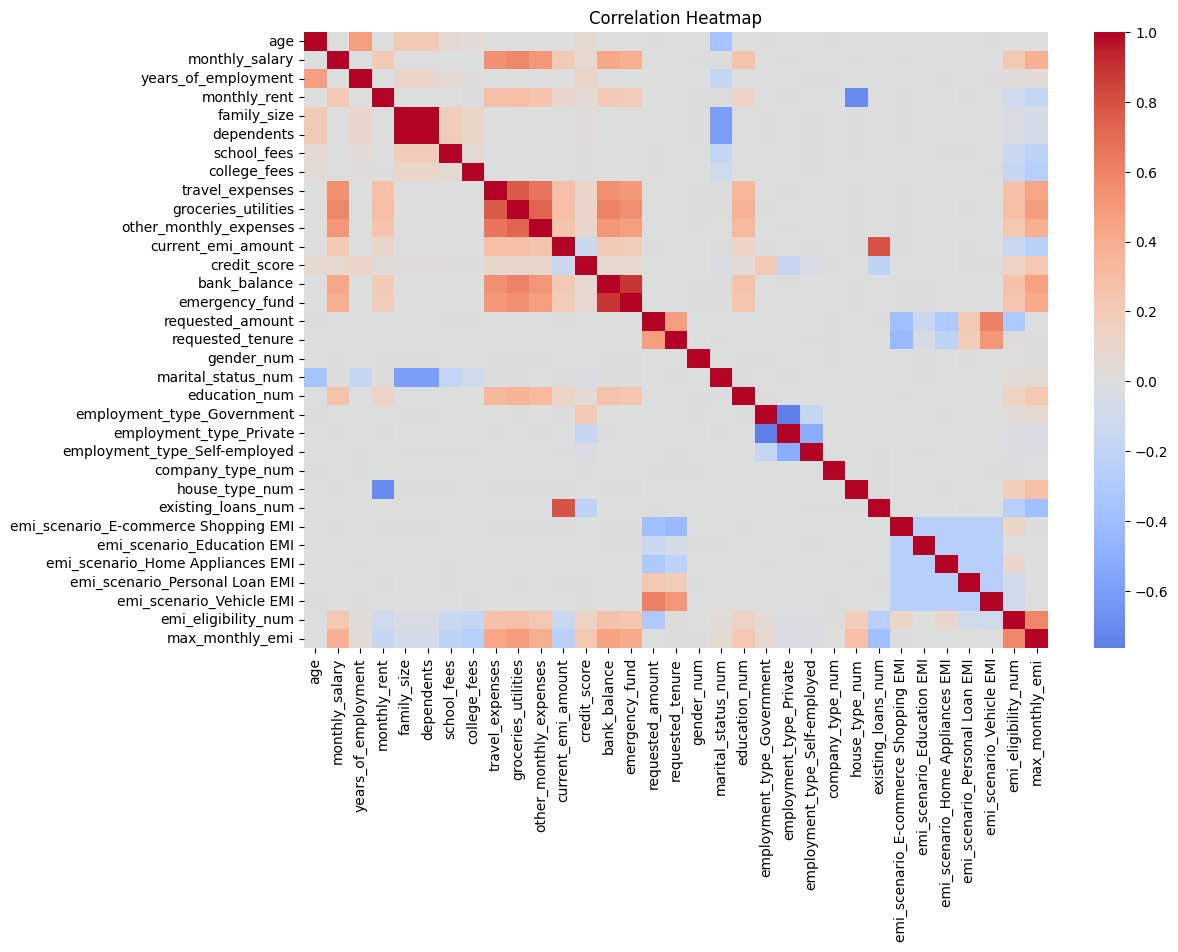

In [193]:
plt.figure(figsize=(12,8))
sn.heatmap(df_preprocessed[rearranged_cols_for_vis].corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')

In [194]:
df_preprocessed.columns

Index(['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'family_size', 'dependents', 'school_fees', 'college_fees',
       'travel_expenses', 'groceries_utilities', 'other_monthly_expenses',
       'current_emi_amount', 'credit_score', 'bank_balance', 'emergency_fund',
       'requested_amount', 'requested_tenure', 'max_monthly_emi', 'gender_num',
       'marital_status_num', 'education_num', 'employment_type_Government',
       'employment_type_Private', 'employment_type_Self-employed',
       'company_type_num', 'house_type_num', 'existing_loans_num',
       'emi_scenario_E-commerce Shopping EMI', 'emi_scenario_Education EMI',
       'emi_scenario_Home Appliances EMI', 'emi_scenario_Personal Loan EMI',
       'emi_scenario_Vehicle EMI', 'emi_eligibility_num'],
      dtype='object')

Text(0.5, 1.0, 'Correlation Heatmap')

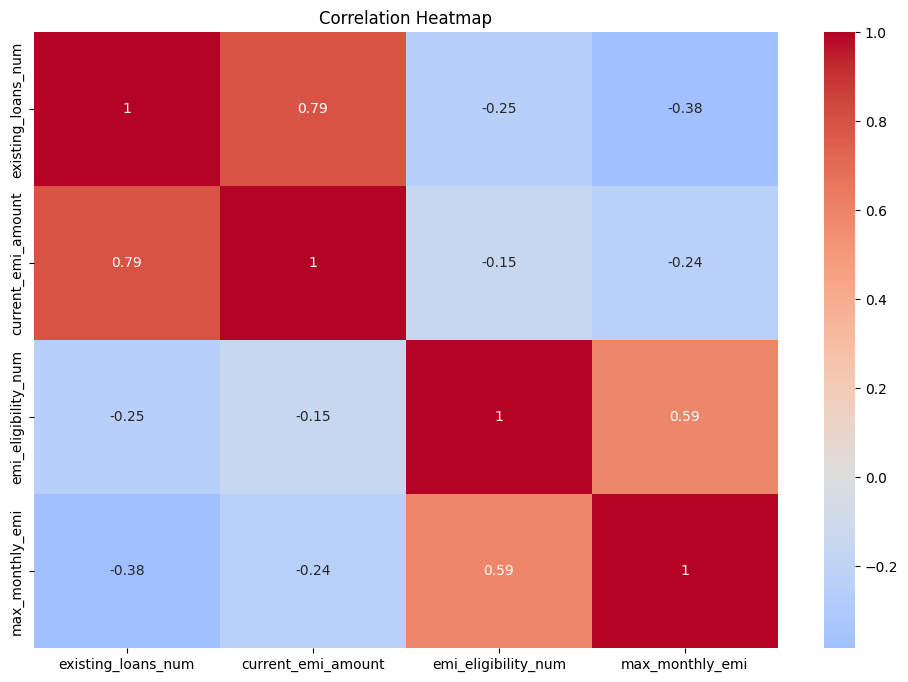

In [195]:
# dynamic heatmap to see specfiic correlations ...

plt.figure(figsize=(12,8))
sn.heatmap(df_preprocessed[['existing_loans_num','current_emi_amount','emi_eligibility_num', 'max_monthly_emi']].corr(), cmap='coolwarm', center=0, annot=True)
plt.title('Correlation Heatmap')

In [196]:
df_preprocessed = df_preprocessed.drop('dependents', axis=1)

In [197]:
df_preprocessed.shape

(404800, 32)

In [198]:
# since emergency_fund and bank_balance are highly correlated .. we have to drop onr
# and since the corr of bank_balance is higher with target cols than emergency_fund .... we'll drop emergency_fund
df_preprocessed.drop('emergency_fund', axis=1, inplace=True)
df_preprocessed.shape

(404800, 31)

In [199]:
corr = df_preprocessed.corr()

In [200]:
corr['emi_eligibility_num'].sort_values(ascending=False)


emi_eligibility_num                     1.000000
max_monthly_emi                         0.593031
groceries_utilities                     0.290220
bank_balance                            0.265364
travel_expenses                         0.264248
other_monthly_expenses                  0.229149
monthly_salary                          0.224688
house_type_num                          0.180991
credit_score                            0.141891
education_num                           0.139467
emi_scenario_E-commerce Shopping EMI    0.105491
emi_scenario_Home Appliances EMI        0.103056
employment_type_Government              0.040480
marital_status_num                      0.035786
years_of_employment                     0.018175
requested_tenure                        0.017025
company_type_num                        0.001249
gender_num                              0.000036
age                                    -0.001610
emi_scenario_Education EMI             -0.005574
employment_type_Self

In [201]:
corr['max_monthly_emi'].sort_values(ascending=False)


max_monthly_emi                         1.000000
emi_eligibility_num                     0.593031
groceries_utilities                     0.484695
bank_balance                            0.456028
travel_expenses                         0.440948
other_monthly_expenses                  0.382055
monthly_salary                          0.378284
house_type_num                          0.283630
education_num                           0.232352
credit_score                            0.228814
employment_type_Government              0.067247
marital_status_num                      0.055107
years_of_employment                     0.028887
gender_num                              0.001844
emi_scenario_E-commerce Shopping EMI    0.001837
requested_tenure                        0.001006
emi_scenario_Vehicle EMI                0.000629
company_type_num                        0.000527
emi_scenario_Education EMI             -0.000142
emi_scenario_Home Appliances EMI       -0.000485
age                 

In [202]:
# this only captures linear relationships ... and especially tree based models can capture that non linear relation so we''ll keep low corr colss for now
# may be later for some linear models like linear or logestic regression well remove these low corr and create new df later

df_preprocessed_1 = df_preprocessed.copy()

In [203]:
df_preprocessed.skew().sort_values(ascending=False)

monthly_salary                          4.846455
employment_type_Self-employed           2.664208
years_of_employment                     2.147970
max_monthly_emi                         1.974159
current_emi_amount                      1.777650
monthly_rent                            1.620951
college_fees                            1.539982
emi_scenario_Vehicle EMI                1.500353
emi_scenario_Education EMI              1.500353
emi_scenario_E-commerce Shopping EMI    1.500237
emi_scenario_Personal Loan EMI          1.499620
emi_scenario_Home Appliances EMI        1.499465
employment_type_Government              1.496016
emi_eligibility_num                     1.454976
bank_balance                            1.428576
other_monthly_expenses                  1.404994
requested_amount                        1.386145
travel_expenses                         1.355937
groceries_utilities                     1.228968
marital_status_num                      1.220566
requested_tenure    

In [204]:
df_preprocessed_1.sort_values(by='monthly_salary', ascending=False).head()

,age,monthly_salary,years_of_employment,monthly_rent,family_size,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,requested_amount,requested_tenure,max_monthly_emi,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
281800,32.0,499970.0,2.7,15800.0,3,10800.0,0.0,9600.0,11700.0,8000.0,19400.0,666.0,151900.0,24000.0,7,500.0,0,1,3,1,0,0,4,1,1,1,0,0,0,0,0
24003,48.0,499930.0,3.6,0.0,4,8900.0,0.0,2900.0,5000.0,2900.0,5200.0,651.0,22900.0,341000.0,33,500.0,1,0,2,0,1,0,3,3,1,0,0,0,1,0,0
332144,38.0,499761.0,0.6,11200.0,4,4600.0,0.0,5400.0,13200.0,6500.0,0.0,733.0,462700.0,49000.0,16,8052.0,0,0,2,0,1,0,1,1,0,1,0,0,0,0,2
296341,38.0,499751.0,2.4,0.0,3,10800.0,0.0,4800.0,9600.0,3400.0,0.0,732.0,94700.0,316000.0,14,6000.0,1,0,2,0,1,0,3,2,0,0,1,0,0,0,0
97121,38.0,499661.0,1.1,0.0,4,0.0,0.0,2000.0,6000.0,4400.0,9700.0,756.0,199600.0,384000.0,39,6594.0,1,0,3,0,1,0,1,3,1,0,1,0,0,0,0


In [205]:
df_preprocessed_1[df_preprocessed_1.monthly_salary > 400000].shape

(1780, 31)

In [206]:
df_preprocessed_1.sort_values(by='years_of_employment', ascending=False).head()


,age,monthly_salary,years_of_employment,monthly_rent,family_size,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,requested_amount,requested_tenure,max_monthly_emi,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
29843,58.0,39200.0,36.0,13300.0,3,14900.0,14900.0,2600.0,9900.0,7500.0,4300.0,694.0,191300.0,94000.0,23,500.0,0,0,3,0,1,0,3,1,1,1,0,0,0,0,0
8,58.0,47700.0,36.0,0.0,3,15000.0,0.0,6100.0,7300.0,8300.0,0.0,712.0,235600.0,106000.0,14,5500.0,0,0,4,0,1,0,4,2,0,1,0,0,0,0,0
74358,58.0,33500.0,36.0,5200.0,3,2500.0,0.0,2000.0,9200.0,2500.0,0.0,827.0,248200.0,470000.0,26,7986.0,0,0,2,0,1,0,5,1,0,0,0,0,0,1,0
223372,58.0,90000.0,36.0,0.0,3,4400.0,0.0,8300.0,24100.0,11600.0,0.0,779.0,690100.0,169000.0,23,27456.0,0,1,3,0,1,0,3,3,0,1,0,0,0,0,2
300708,58.0,57900.0,36.0,0.0,3,0.0,0.0,5400.0,13000.0,10500.0,0.0,741.0,235200.0,121000.0,19,14500.0,0,0,2,0,1,0,3,3,0,1,0,0,0,0,2


In [207]:
df_preprocessed_1[df_preprocessed_1.years_of_employment > 35].shape

(2092, 31)

In [208]:
df_preprocessed_1.sort_values(by='max_monthly_emi', ascending=False).head(20)

,age,monthly_salary,years_of_employment,monthly_rent,family_size,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,requested_amount,requested_tenure,max_monthly_emi,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
148152,48.0,210200.0,12.0,0.0,3,0.0,0.0,22300.0,41900.0,20600.0,0.0,850.0,1314700.0,704000.0,84,91040.4,0,0,4,1,0,0,1,3,0,0,0,0,0,1,2
145906,32.0,205600.0,10.0,0.0,4,0.0,0.0,12300.0,31300.0,26900.0,0.0,795.0,1414300.0,723000.0,39,89166.0,1,0,4,0,1,0,1,3,0,0,0,0,0,1,2
164061,32.0,225300.0,1.6,0.0,4,3900.0,0.0,25500.0,37600.0,11300.0,0.0,795.0,951900.0,205000.0,31,88200.0,1,0,4,0,1,0,4,2,0,0,0,1,0,0,2
232316,38.0,194300.0,14.3,0.0,4,9400.0,0.0,15900.0,39500.0,12900.0,0.0,828.0,1214800.0,476000.0,47,84651.6,1,0,4,1,0,0,3,3,0,0,1,0,0,0,2
122348,58.0,224100.0,33.5,0.0,2,8200.0,0.0,13700.0,47500.0,32300.0,0.0,835.0,598900.0,332000.0,38,80784.0,1,1,4,1,0,0,5,2,0,0,0,0,1,0,2
340297,38.0,184900.0,6.7,0.0,3,2900.0,0.0,14000.0,30900.0,18600.0,0.0,771.0,401700.0,345000.0,65,78210.0,0,0,4,1,0,0,3,3,0,0,0,0,0,1,2
331767,32.0,166200.0,6.1,0.0,2,0.0,0.0,11300.0,39100.0,9300.0,0.0,829.0,1124300.0,49000.0,32,77319.0,0,0,4,1,0,0,5,2,0,0,0,1,0,0,2
25924,58.0,188600.0,12.4,0.0,2,8800.0,0.0,12800.0,30300.0,10500.0,0.0,660.0,1375600.0,140000.0,49,76351.0,1,0,4,1,0,0,3,3,0,0,0,0,0,1,2
45724,48.0,234500.0,6.0,0.0,3,12800.0,22100.0,21500.0,36300.0,15600.0,0.0,829.0,1290100.0,932000.0,41,75720.0,1,0,4,0,1,0,5,3,0,0,0,0,1,0,2
386415,48.0,194400.0,15.1,0.0,2,0.0,0.0,18900.0,33900.0,38000.0,0.0,843.0,1470600.0,446000.0,42,75213.6,1,0,4,1,0,0,4,3,0,0,1,0,0,0,2


In [209]:
# may be just transform n scale .. every data is important so no need to remove unless its extream or outliers

In [210]:
df_preprocessed_1.columns

Index(['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'family_size', 'school_fees', 'college_fees', 'travel_expenses',
       'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount',
       'credit_score', 'bank_balance', 'requested_amount', 'requested_tenure',
       'max_monthly_emi', 'gender_num', 'marital_status_num', 'education_num',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'company_type_num', 'house_type_num',
       'existing_loans_num', 'emi_scenario_E-commerce Shopping EMI',
       'emi_scenario_Education EMI', 'emi_scenario_Home Appliances EMI',
       'emi_scenario_Personal Loan EMI', 'emi_scenario_Vehicle EMI',
       'emi_eligibility_num'],
      dtype='object')

In [211]:
# since tree based models like randomforest , xgboost arent affected by skewness n outliers much .. 
# it dosent need and transformation or scaling 
# those doesnt improve theri performance ..

# but for other non-tree models like svm,linear,knn etc... are indeed affected by all those .. so transformation is needed .. 
# so we'll create 2 df for both of them .

In [212]:
# okay soo .. aparently .. tree models dont care even if scaling/tranforming is done too .. 
# so creating 2 df is kinda pointless .. so lets go with one itself.

In [213]:
df_preprocessed_1

,age,monthly_salary,years_of_employment,monthly_rent,family_size,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,current_emi_amount,credit_score,bank_balance,requested_amount,requested_tenure,max_monthly_emi,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
0,38.0,82600.0,0.9,20000.0,3,0.0,0.0,7200.0,19500.0,13200.0,23700.0,660.0,303200.0,850000.0,15,500.0,0,0,4,0,1,0,3,1,1,0,0,0,1,0,0
1,38.0,21500.0,7.0,0.0,2,5100.0,0.0,1400.0,5400.0,3500.0,4100.0,714.0,92500.0,128000.0,19,700.0,0,0,2,0,1,0,5,2,1,1,0,0,0,0,0
2,38.0,86100.0,5.8,0.0,4,0.0,0.0,10200.0,19400.0,6000.0,0.0,650.0,672100.0,306000.0,16,27775.0,1,0,4,0,1,0,1,3,0,0,1,0,0,0,2
3,58.0,66800.0,2.2,0.0,5,11400.0,0.0,6200.0,11900.0,7900.0,0.0,685.0,440900.0,304000.0,83,16170.0,0,0,1,0,1,0,3,3,0,0,0,0,0,1,2
4,48.0,57300.0,3.4,0.0,4,9400.0,21300.0,3600.0,16200.0,8100.0,0.0,770.0,97300.0,252000.0,7,500.0,0,0,4,0,1,0,3,2,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
404795,27.0,32400.0,5.0,10400.0,4,2800.0,7000.0,2200.0,4900.0,6100.0,0.0,649.0,62000.0,506000.0,47,500.0,1,0,2,0,1,0,4,1,0,0,0,0,1,0,0
404796,38.0,49200.0,1.9,0.0,5,14000.0,0.0,2600.0,13600.0,8600.0,0.0,712.0,142200.0,708000.0,33,5200.0,1,0,3,0,1,0,5,3,0,0,0,0,1,0,0
404797,32.0,25700.0,3.2,6300.0,1,0.0,0.0,2000.0,4600.0,2500.0,0.0,676.0,191600.0,93000.0,21,5665.0,1,1,2,0,1,0,5,1,0,0,0,1,0,0,1
404798,48.0,47200.0,3.0,0.0,4,0.0,0.0,7000.0,8900.0,7200.0,0.0,784.0,170400.0,144000.0,36,14460.0,1,0,2,0,1,0,5,3,0,0,0,1,0,0,2


In [214]:
df_preprocessed_1.requested_tenure.unique()

array([15, 19, 16, 83,  7, 53, 11, 12, 14,  3, 77, 41, 21, 60, 61, 33, 35,
       57, 36, 63, 20, 75,  8, 23, 49, 45, 80, 34, 18, 59,  9, 48, 22, 42,
       13, 39, 55, 44, 37, 10, 25,  6, 24, 31, 28, 43, 29, 26, 58, 32, 69,
       46, 17,  5, 27, 30, 52, 66, 79, 40, 47, 51, 67, 74, 50, 38, 54, 76,
       64, 56, 71, 68, 73, 65, 72,  4, 81, 62, 70, 84, 78, 82])

In [215]:
cols_to_be_transformed = ['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
 'school_fees', 'college_fees', 'travel_expenses', 'groceries_utilities',
 'other_monthly_expenses', 'current_emi_amount', 'credit_score',
 'bank_balance', 'requested_amount', 'requested_tenure', 'max_monthly_emi']


In [216]:
df_preprocessed_1.columns

Index(['age', 'monthly_salary', 'years_of_employment', 'monthly_rent',
       'family_size', 'school_fees', 'college_fees', 'travel_expenses',
       'groceries_utilities', 'other_monthly_expenses', 'current_emi_amount',
       'credit_score', 'bank_balance', 'requested_amount', 'requested_tenure',
       'max_monthly_emi', 'gender_num', 'marital_status_num', 'education_num',
       'employment_type_Government', 'employment_type_Private',
       'employment_type_Self-employed', 'company_type_num', 'house_type_num',
       'existing_loans_num', 'emi_scenario_E-commerce Shopping EMI',
       'emi_scenario_Education EMI', 'emi_scenario_Home Appliances EMI',
       'emi_scenario_Personal Loan EMI', 'emi_scenario_Vehicle EMI',
       'emi_eligibility_num'],
      dtype='object')

In [217]:
'''
existing_loans_num                      0.411897
education_num                           0.305021
house_type_num                          0.091839
family_size                             0.022211
gender_num                             -0.408985
'''

'\nexisting_loans_num                      0.411897\neducation_num                           0.305021\nhouse_type_num                          0.091839\nfamily_size                             0.022211\ngender_num                             -0.408985\n'

In [218]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method='yeo-johnson')

df_transformed = df_preprocessed_1.copy()
df_transformed[cols_to_be_transformed] = pt.fit_transform(df_preprocessed_1[cols_to_be_transformed])

print(df_transformed[cols_to_be_transformed].skew())


age                       0.052647
monthly_salary            0.003289
years_of_employment       0.075366
monthly_rent              0.380984
school_fees              -0.141750
college_fees              1.031293
travel_expenses          -0.007658
groceries_utilities      -0.007968
other_monthly_expenses   -0.009228
current_emi_amount        0.417353
credit_score              0.649818
bank_balance             -0.029438
requested_amount         -0.020197
requested_tenure         -0.029658
max_monthly_emi          -0.047127
dtype: float64


In [219]:
import joblib
joblib.dump(pt, 'yeo_johnson_transformer.pkl')
print("Transformer saved successfully ✅")


Transformer saved successfully ✅


In [220]:
# 2 cols still skewed slightly but if we do further transformation or change it into log1p for those 2 alone ..
# we might lose the consistent scaling that Yeo-Johnson did for others..
# also as our dataset is big this light skew wont affect much so we'll leave it as it is now.

In [221]:
df_transformed.describe().T

,count,mean,std,min,25%,50%,75%,max
age,404800.0,8.701059e-15,1.000001,-1.783736,-0.695383,0.098184,1.039265,1.754221
monthly_salary,404800.0,2.183725e-15,1.000001,-4.405390,-0.622721,0.043191,0.647855,4.104024
years_of_employment,404800.0,-1.169727e-16,1.000001,-1.474295,-0.868625,0.026468,0.806989,2.138336
monthly_rent,404800.0,6.599903e-17,1.000001,-0.828911,-0.828911,-0.828911,1.189973,1.400255
family_size,404800.0,2.940425e+00,1.075199,1.000000,2.000000,3.000000,4.000000,5.000000
school_fees,404800.0,-8.313069e-17,1.000001,-1.084864,-1.084864,0.661790,0.958657,1.102178
college_fees,404800.0,6.319056e-17,1.000001,-0.609510,-0.609510,-0.609510,1.613881,1.659272
travel_expenses,404800.0,3.458279e-16,1.000001,-3.136456,-0.699917,0.000740,0.712815,3.425072
groceries_utilities,404800.0,-1.200621e-17,1.000001,-3.005400,-0.686133,0.016864,0.700369,3.803661
other_monthly_expenses,404800.0,3.864805e-16,1.000001,-3.155994,-0.706859,-0.006322,0.705287,3.523206


In [222]:
#df_preprocessed.to_csv('df_preprocessed.csv', index=False)
#df_transformed.to_csv('df_transformed.csv', index=False)


In [224]:
obj_cols_for_mapping=df.select_dtypes(include=['object']).columns
obj_cols_for_mapping

Index(['gender', 'marital_status', 'education', 'employment_type',
       'company_type', 'house_type', 'existing_loans', 'emi_scenario',
       'emi_eligibility'],
      dtype='object')

In [226]:
df.head()

,age,gender,marital_status,education,monthly_salary,employment_type,years_of_employment,company_type,house_type,monthly_rent,family_size,dependents,school_fees,college_fees,travel_expenses,groceries_utilities,other_monthly_expenses,existing_loans,current_emi_amount,credit_score,bank_balance,emergency_fund,emi_scenario,requested_amount,requested_tenure,emi_eligibility,max_monthly_emi,gender_num,marital_status_num,education_num,employment_type_Government,employment_type_Private,employment_type_Self-employed,company_type_num,house_type_num,existing_loans_num,emi_scenario_E-commerce Shopping EMI,emi_scenario_Education EMI,emi_scenario_Home Appliances EMI,emi_scenario_Personal Loan EMI,emi_scenario_Vehicle EMI,emi_eligibility_num
0,38.0,female,Married,Professional,82600.0,Private,0.9,Mid-size,Rented,20000.0,3,2,0.0,0.0,7200.0,19500.0,13200.0,Yes,23700.0,660.0,303200.0,70200.0,Personal Loan EMI,850000.0,15,Not_Eligible,500.0,0,0,4,0,1,0,3,1,1,0,0,0,1,0,0
1,38.0,female,Married,Graduate,21500.0,Private,7.0,MNC,Family,0.0,2,1,5100.0,0.0,1400.0,5400.0,3500.0,Yes,4100.0,714.0,92500.0,26900.0,E-commerce Shopping EMI,128000.0,19,Not_Eligible,700.0,0,0,2,0,1,0,5,2,1,1,0,0,0,0,0
2,38.0,male,Married,Professional,86100.0,Private,5.8,Startup,Own,0.0,4,3,0.0,0.0,10200.0,19400.0,6000.0,No,0.0,650.0,672100.0,324200.0,Education EMI,306000.0,16,Eligible,27775.0,1,0,4,0,1,0,1,3,0,0,1,0,0,0,2
3,58.0,female,Married,High School,66800.0,Private,2.2,Mid-size,Own,0.0,5,4,11400.0,0.0,6200.0,11900.0,7900.0,No,0.0,685.0,440900.0,178100.0,Vehicle EMI,304000.0,83,Eligible,16170.0,0,0,1,0,1,0,3,3,0,0,0,0,0,1,2
4,48.0,female,Married,Professional,57300.0,Private,3.4,Mid-size,Family,0.0,4,3,9400.0,21300.0,3600.0,16200.0,8100.0,No,0.0,770.0,97300.0,28200.0,Home Appliances EMI,252000.0,7,Not_Eligible,500.0,0,0,4,0,1,0,3,2,0,0,0,1,0,0,0


In [227]:
mapping_ordinal = ['gender', 'marital_status', 'education','company_type', 'house_type', 'existing_loans', 'emi_eligibility']
mapping_ordinal_num = ['gender_num', 'marital_status_num', 'education_num', 'company_type_num', 'house_type_num', 'existing_loans_num', 'emi_eligibility_num']

for col, col_num in zip(mapping_ordinal, mapping_ordinal_num):
    print(f"{col} : {df[col].unique()}  -->  {col_num} : {df[col_num].unique()}")

gender : ['female' 'male']  -->  gender_num : [0 1]
marital_status : ['Married' 'Single']  -->  marital_status_num : [0 1]
education : ['Professional' 'Graduate' 'High School' 'Post Graduate']  -->  education_num : [4 2 1 3]
company_type : ['Mid-size' 'MNC' 'Startup' 'Large Indian' 'Small']  -->  company_type_num : [3 5 1 4 2]
house_type : ['Rented' 'Family' 'Own']  -->  house_type_num : [1 2 3]
existing_loans : ['Yes' 'No']  -->  existing_loans_num : [1 0]
emi_eligibility : ['Not_Eligible' 'Eligible' 'High_Risk']  -->  emi_eligibility_num : [0 2 1]


In [228]:
df.employment_type.unique()

array(['Private', 'Government', 'Self-employed'], dtype=object)

In [229]:
df.emi_scenario.unique()

array(['Personal Loan EMI', 'E-commerce Shopping EMI', 'Education EMI',
       'Vehicle EMI', 'Home Appliances EMI'], dtype=object)